In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
jeep_df = pd.read_csv("export_jeep_pool.csv")
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times
0,0,20,0,0,0.0025,240,NaN,15559|26570|29371|32172|33943|37865|57810|6553...,14719|23770|26571|29372|32173|36185|56629|6273...
1,1,20,1,1,0.0025,240,NaN,12285|26854|29655|32433|34114|40226|54224|6593...,11445|24054|26855|29656|32434|38546|53174|6313...
2,2,20,0,0,0.0025,240,NaN,24477|27278|30079|32688|34369|39258|62101|6574...,21677|24478|27279|30080|32689|37578|59301|6294...
3,3,20,0,0,0.0025,222,4471|4477,20104|27140|29941|32605|34286|41868|56355|6616...,19264|24340|27141|29942|32606|40188|55305|6336...
4,4,20,1,1,0.0025,237,4452|4454|4455|4456|4461|4462|4463|4464|4465|4...,24672|27473|30274|32805|34486|40985|63900|6670...,21872|24673|27474|30275|32806|39305|61100|6390...
5,5,20,0,0,0.0025,220,NaN,24566|27376|30177|32746|34427|42683|59154|6646...,21766|24576|27377|30178|32747|41003|57133|6366...
6,6,20,1,1,0.0025,220,NaN,24882|27683|30484|32931|34612|42438|64237|6703...,22082|24883|27684|30485|32932|40758|61437|6423...
7,7,20,0,0,0.0025,220,NaN,24754|27587|30388|32873|34554|43688|62152|6673...,21954|24787|27588|30389|32874|42301|59352|6393...
8,8,20,1,1,0.0025,220,NaN,25165|27966|30767|33100|34781|43351|64422|6722...,22365|25166|27967|30768|33101|41762|61622|6442...
9,9,20,0,0,0.0025,220,NaN,24978|27779|30580|32988|34669|44323|64030|6697...,22178|24979|27780|30581|32989|43273|61230|6417...


In [4]:
jeep_df["arrive_times"] = jeep_df["arrive_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["arrive_times"]

0     [15559, 26570, 29371, 32172, 33943, 37865, 578...
1     [12285, 26854, 29655, 32433, 34114, 40226, 542...
2     [24477, 27278, 30079, 32688, 34369, 39258, 621...
3     [20104, 27140, 29941, 32605, 34286, 41868, 563...
4     [24672, 27473, 30274, 32805, 34486, 40985, 639...
5     [24566, 27376, 30177, 32746, 34427, 42683, 591...
6     [24882, 27683, 30484, 32931, 34612, 42438, 642...
7     [24754, 27587, 30388, 32873, 34554, 43688, 621...
8     [25165, 27966, 30767, 33100, 34781, 43351, 644...
9     [24978, 27779, 30580, 32988, 34669, 44323, 640...
10    [25466, 28267, 31068, 33281, 34962, 44043, 647...
11    [25382, 28183, 30984, 33231, 34912, 46332, 642...
12    [25800, 28601, 31402, 33481, 35624, 45902, 649...
13    [25563, 28364, 31165, 33339, 35020, 48901, 645...
14    [26106, 28907, 31708, 33665, 36676, 48276, 650...
15    [25757, 28558, 31359, 33456, 35137, 51508, 647...
16    [26297, 29098, 31899, 33780, 37562, 49791, 653...
17    [26061, 28862, 31663, 33638, 36277, 53875,

In [5]:
jeep_df["embark_times"] = jeep_df["embark_times"].str.split('|').apply(lambda lst: list(map(int, lst)))

jeep_df["embark_times"]

0     [14719, 23770, 26571, 29372, 32173, 36185, 566...
1     [11445, 24054, 26855, 29656, 32434, 38546, 531...
2     [21677, 24478, 27279, 30080, 32689, 37578, 593...
3     [19264, 24340, 27141, 29942, 32606, 40188, 553...
4     [21872, 24673, 27474, 30275, 32806, 39305, 611...
5     [21766, 24576, 27377, 30178, 32747, 41003, 571...
6     [22082, 24883, 27684, 30485, 32932, 40758, 614...
7     [21954, 24787, 27588, 30389, 32874, 42301, 593...
8     [22365, 25166, 27967, 30768, 33101, 41762, 616...
9     [22178, 24979, 27780, 30581, 32989, 43273, 612...
10    [22666, 25467, 28268, 31069, 33282, 42870, 619...
11    [22582, 25383, 28184, 30985, 33232, 45282, 614...
12    [23000, 25801, 28602, 31403, 33944, 44852, 621...
13    [22763, 25564, 28365, 31166, 33340, 47851, 617...
14    [23306, 26107, 28908, 31709, 34996, 47226, 622...
15    [22957, 25758, 28559, 31360, 33457, 50458, 619...
16    [23497, 26298, 29099, 31900, 35882, 48741, 625...
17    [23261, 26062, 28863, 31664, 34597, 52825,

In [6]:
jeep_df["queue_start_times"] = jeep_df["arrive_times"].apply(
    lambda times: [0] + times[:-1]
)



In [7]:
jeep_df["queue_wait_times"] = jeep_df.apply(
    lambda row: [eb - qs  for qs, eb in zip(row["queue_start_times"], row["embark_times"])],
    axis=1
)

In [8]:
jeep_df[["embark_times", "arrive_times", "queue_start_times", "queue_wait_times"]].head()


,embark_times,arrive_times,queue_start_times,queue_wait_times
0,"[14719, 23770, 26571, 29372, 32173, 36185, 566...","[15559, 26570, 29371, 32172, 33943, 37865, 578...","[0, 15559, 26570, 29371, 32172, 33943, 37865, ...","[14719, 8211, 1, 1, 1, 2242, 18764, 4928, 1, 1..."
1,"[11445, 24054, 26855, 29656, 32434, 38546, 531...","[12285, 26854, 29655, 32433, 34114, 40226, 542...","[0, 12285, 26854, 29655, 32433, 34114, 40226, ...","[11445, 11769, 1, 1, 1, 4432, 12948, 8909, 1, ..."
2,"[21677, 24478, 27279, 30080, 32689, 37578, 593...","[24477, 27278, 30079, 32688, 34369, 39258, 621...","[0, 24477, 27278, 30079, 32688, 34369, 39258, ...","[21677, 1, 1, 1, 1, 3209, 20043, 848, 1, 1, 1,..."
3,"[19264, 24340, 27141, 29942, 32606, 40188, 553...","[20104, 27140, 29941, 32605, 34286, 41868, 563...","[0, 20104, 27140, 29941, 32605, 34286, 41868, ...","[19264, 4236, 1, 1, 1, 5902, 13437, 7010, 1, 1..."
4,"[21872, 24673, 27474, 30275, 32806, 39305, 611...","[24672, 27473, 30274, 32805, 34486, 40985, 639...","[0, 24672, 27473, 30274, 32805, 34486, 40985, ...","[21872, 1, 1, 1, 1, 4819, 20115, 1, 1, 1, 1]"


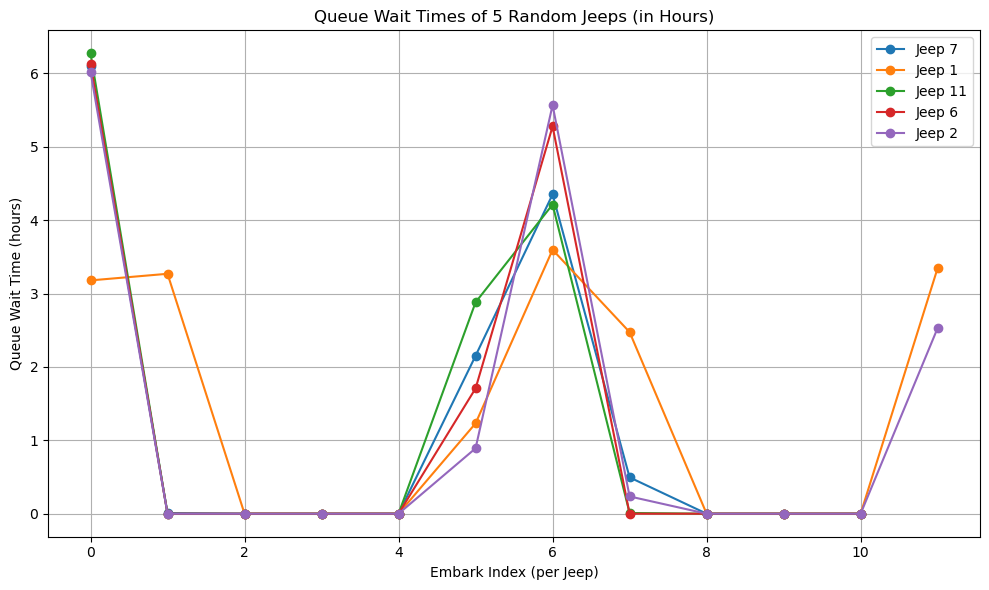

In [9]:
import random

# Randomly select 5 jeep indices
random_indices = random.sample(range(len(jeep_df)), 5)

# Plot each selected jeep's queue wait times (converted to hours)
plt.figure(figsize=(10, 6))
for idx in random_indices:
    wait_times_sec = jeep_df.loc[idx, "queue_wait_times"]
    wait_times_hr = [t / 3600 for t in wait_times_sec]  # Convert to hours
    plt.plot(range(len(wait_times_hr)), wait_times_hr, marker='o', label=f"Jeep {idx}")

plt.xlabel("Embark Index (per Jeep)")
plt.ylabel("Queue Wait Time (hours)")
plt.title("Queue Wait Times of 5 Random Jeeps (in Hours)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [10]:
jeep_df["embark_hours"] = jeep_df["embark_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["embark_hours"]

0     [4.09, 6.6, 7.38, 8.16, 8.94, 10.05, 15.73, 17...
1     [3.18, 6.68, 7.46, 8.24, 9.01, 10.71, 14.77, 1...
2     [6.02, 6.8, 7.58, 8.36, 9.08, 10.44, 16.47, 17...
3     [5.35, 6.76, 7.54, 8.32, 9.06, 11.16, 15.36, 1...
4     [6.08, 6.85, 7.63, 8.41, 9.11, 10.92, 16.97, 1...
5     [6.05, 6.83, 7.6, 8.38, 9.1, 11.39, 15.87, 17....
6     [6.13, 6.91, 7.69, 8.47, 9.15, 11.32, 17.07, 1...
7     [6.1, 6.89, 7.66, 8.44, 9.13, 11.75, 16.49, 17...
8     [6.21, 6.99, 7.77, 8.55, 9.19, 11.6, 17.12, 17...
9     [6.16, 6.94, 7.72, 8.49, 9.16, 12.02, 17.01, 1...
10    [6.3, 7.07, 7.85, 8.63, 9.24, 11.91, 17.2, 17....
11    [6.27, 7.05, 7.83, 8.61, 9.23, 12.58, 17.08, 1...
12    [6.39, 7.17, 7.95, 8.72, 9.43, 12.46, 17.26, 1...
13    [6.32, 7.1, 7.88, 8.66, 9.26, 13.29, 17.17, 17...
14    [6.47, 7.25, 8.03, 8.81, 9.72, 13.12, 17.3, 18...
15    [6.38, 7.16, 7.93, 8.71, 9.29, 14.02, 17.21, 1...
16    [6.53, 7.3, 8.08, 8.86, 9.97, 13.54, 17.38, 18...
17    [6.46, 7.24, 8.02, 8.8, 9.61, 14.67, 17.27

In [11]:
jeep_df["arrive_hours"] = jeep_df["arrive_times"].apply(
    lambda times: [round(int(t) / 3600, 2) for t in times]
)

jeep_df["arrive_hours"]

0     [4.32, 7.38, 8.16, 8.94, 9.43, 10.52, 16.06, 1...
1     [3.41, 7.46, 8.24, 9.01, 9.48, 11.17, 15.06, 1...
2     [6.8, 7.58, 8.36, 9.08, 9.55, 10.9, 17.25, 18....
3     [5.58, 7.54, 8.32, 9.06, 9.52, 11.63, 15.65, 1...
4     [6.85, 7.63, 8.41, 9.11, 9.58, 11.38, 17.75, 1...
5     [6.82, 7.6, 8.38, 9.1, 9.56, 11.86, 16.43, 18....
6     [6.91, 7.69, 8.47, 9.15, 9.61, 11.79, 17.84, 1...
7     [6.88, 7.66, 8.44, 9.13, 9.6, 12.14, 17.26, 18...
8     [6.99, 7.77, 8.55, 9.19, 9.66, 12.04, 17.89, 1...
9     [6.94, 7.72, 8.49, 9.16, 9.63, 12.31, 17.79, 1...
10    [7.07, 7.85, 8.63, 9.24, 9.71, 12.23, 17.98, 1...
11    [7.05, 7.83, 8.61, 9.23, 9.7, 12.87, 17.86, 18...
12    [7.17, 7.94, 8.72, 9.3, 9.9, 12.75, 18.03, 18....
13    [7.1, 7.88, 8.66, 9.26, 9.73, 13.58, 17.94, 18...
14    [7.25, 8.03, 8.81, 9.35, 10.19, 13.41, 18.08, ...
15    [7.15, 7.93, 8.71, 9.29, 9.76, 14.31, 17.99, 1...
16    [7.3, 8.08, 8.86, 9.38, 10.43, 13.83, 18.16, 1...
17    [7.24, 8.02, 8.8, 9.34, 10.08, 14.97, 18.0

In [12]:
jeep_df["gross_profit"] = jeep_df["passenger_served"] * 13

jeep_df["gross_profit"]

0     3120
1     3120
2     3120
3     2886
4     3081
5     2860
6     2860
7     2860
8     2860
9     2860
10    2860
11    2860
12    2860
13    2860
14    2860
15    2860
16    2860
17    2860
18    2860
19    2860
Name: gross_profit, dtype: int64

In [13]:
route_distance = 5 #change if needed
gas_price = 60
liters_per_km = 0.181818
jeep_df["gas_expense"] = len(jeep_df["embark_times"]) * route_distance * liters_per_km * gas_price

In [14]:
jeep_df["gas_expense"]

0     1090.908
1     1090.908
2     1090.908
3     1090.908
4     1090.908
5     1090.908
6     1090.908
7     1090.908
8     1090.908
9     1090.908
10    1090.908
11    1090.908
12    1090.908
13    1090.908
14    1090.908
15    1090.908
16    1090.908
17    1090.908
18    1090.908
19    1090.908
Name: gas_expense, dtype: float64

In [15]:
jeep_df["net_profit"] = jeep_df["gross_profit"] - jeep_df["gas_expense"]

In [16]:
jeep_df

,id,max_passengers,state,distance,speed,passenger_served,current_passengers,arrive_times,embark_times,queue_start_times,queue_wait_times,embark_hours,arrive_hours,gross_profit,gas_expense,net_profit
0,0,20,0,0,0.0025,240,NaN,"[15559, 26570, 29371, 32172, 33943, 37865, 578...","[14719, 23770, 26571, 29372, 32173, 36185, 566...","[0, 15559, 26570, 29371, 32172, 33943, 37865, ...","[14719, 8211, 1, 1, 1, 2242, 18764, 4928, 1, 1...","[4.09, 6.6, 7.38, 8.16, 8.94, 10.05, 15.73, 17...","[4.32, 7.38, 8.16, 8.94, 9.43, 10.52, 16.06, 1...",3120,1090.908,2029.092
1,1,20,1,1,0.0025,240,NaN,"[12285, 26854, 29655, 32433, 34114, 40226, 542...","[11445, 24054, 26855, 29656, 32434, 38546, 531...","[0, 12285, 26854, 29655, 32433, 34114, 40226, ...","[11445, 11769, 1, 1, 1, 4432, 12948, 8909, 1, ...","[3.18, 6.68, 7.46, 8.24, 9.01, 10.71, 14.77, 1...","[3.41, 7.46, 8.24, 9.01, 9.48, 11.17, 15.06, 1...",3120,1090.908,2029.092
2,2,20,0,0,0.0025,240,NaN,"[24477, 27278, 30079, 32688, 34369, 39258, 621...","[21677, 24478, 27279, 30080, 32689, 37578, 593...","[0, 24477, 27278, 30079, 32688, 34369, 39258, ...","[21677, 1, 1, 1, 1, 3209, 20043, 848, 1, 1, 1,...","[6.02, 6.8, 7.58, 8.36, 9.08, 10.44, 16.47, 17...","[6.8, 7.58, 8.36, 9.08, 9.55, 10.9, 17.25, 18....",3120,1090.908,2029.092
3,3,20,0,0,0.0025,222,4471|4477,"[20104, 27140, 29941, 32605, 34286, 41868, 563...","[19264, 24340, 27141, 29942, 32606, 40188, 553...","[0, 20104, 27140, 29941, 32605, 34286, 41868, ...","[19264, 4236, 1, 1, 1, 5902, 13437, 7010, 1, 1...","[5.35, 6.76, 7.54, 8.32, 9.06, 11.16, 15.36, 1...","[5.58, 7.54, 8.32, 9.06, 9.52, 11.63, 15.65, 1...",2886,1090.908,1795.092
4,4,20,1,1,0.0025,237,4452|4454|4455|4456|4461|4462|4463|4464|4465|4...,"[24672, 27473, 30274, 32805, 34486, 40985, 639...","[21872, 24673, 27474, 30275, 32806, 39305, 611...","[0, 24672, 27473, 30274, 32805, 34486, 40985, ...","[21872, 1, 1, 1, 1, 4819, 20115, 1, 1, 1, 1]","[6.08, 6.85, 7.63, 8.41, 9.11, 10.92, 16.97, 1...","[6.85, 7.63, 8.41, 9.11, 9.58, 11.38, 17.75, 1...",3081,1090.908,1990.092
5,5,20,0,0,0.0025,220,NaN,"[24566, 27376, 30177, 32746, 34427, 42683, 591...","[21766, 24576, 27377, 30178, 32747, 41003, 571...","[0, 24566, 27376, 30177, 32746, 34427, 42683, ...","[21766, 10, 1, 1, 1, 6576, 14450, 4507, 1, 1, 1]","[6.05, 6.83, 7.6, 8.38, 9.1, 11.39, 15.87, 17....","[6.82, 7.6, 8.38, 9.1, 9.56, 11.86, 16.43, 18....",2860,1090.908,1769.092
6,6,20,1,1,0.0025,220,NaN,"[24882, 27683, 30484, 32931, 34612, 42438, 642...","[22082, 24883, 27684, 30485, 32932, 40758, 614...","[0, 24882, 27683, 30484, 32931, 34612, 42438, ...","[22082, 1, 1, 1, 1, 6146, 18999, 1, 1, 1, 1]","[6.13, 6.91, 7.69, 8.47, 9.15, 11.32, 17.07, 1...","[6.91, 7.69, 8.47, 9.15, 9.61, 11.79, 17.84, 1...",2860,1090.908,1769.092
7,7,20,0,0,0.0025,220,NaN,"[24754, 27587, 30388, 32873, 34554, 43688, 621...","[21954, 24787, 27588, 30389, 32874, 42301, 593...","[0, 24754, 27587, 30388, 32873, 34554, 43688, ...","[21954, 33, 1, 1, 1, 7747, 15664, 1783, 1, 1, 1]","[6.1, 6.89, 7.66, 8.44, 9.13, 11.75, 16.49, 17...","[6.88, 7.66, 8.44, 9.13, 9.6, 12.14, 17.26, 18...",2860,1090.908,1769.092
8,8,20,1,1,0.0025,220,NaN,"[25165, 27966, 30767, 33100, 34781, 43351, 644...","[22365, 25166, 27967, 30768, 33101, 41762, 616...","[0, 25165, 27966, 30767, 33100, 34781, 43351, ...","[22365, 1, 1, 1, 1, 6981, 18271, 1, 1, 1, 1]","[6.21, 6.99, 7.77, 8.55, 9.19, 11.6, 17.12, 17...","[6.99, 7.77, 8.55, 9.19, 9.66, 12.04, 17.89, 1...",2860,1090.908,1769.092
9,9,20,0,0,0.0025,220,NaN,"[24978, 27779, 30580, 32988, 34669, 44323, 640...","[22178, 24979, 27780, 30581, 32989, 43273, 612...","[0, 24978, 27779, 30580, 32988, 34669, 44323, ...","[22178, 1, 1, 1, 1, 8604, 16907, 141, 1, 1, 1]","[6.16, 6.94, 7.72, 8.49, 9.16, 12.02, 17.01, 1...","[6.94, 7.72, 8.49, 9.16, 9.63, 12.31, 17.79, 1...",2860,1090.908,1769.092


In [17]:
passenger_df = pd.read_csv("export_passenger_pool.csv")

passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]] = passenger_df[["terminal_arrival_time","board_time","leave_time","destination_arrival_time"]].apply(lambda times: [round(int(t) / 3600, 2) for t in times] )

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal
0,0,0.07,0.07,4.09,4.32,0,0
1,1,0.13,0.13,3.18,3.41,1,1
2,2,0.14,0.14,4.09,4.32,0,0
3,3,0.19,0.19,3.18,3.41,1,1
4,4,0.22,0.22,3.18,3.41,1,1
...,...,...,...,...,...,...,...
4474,4474,23.80,23.80,0.00,0.00,4,1
4475,4475,23.86,23.86,0.00,0.00,4,1
4476,4476,23.87,23.87,0.00,0.00,4,1
4477,4477,23.93,23.93,0.00,0.00,3,0


In [18]:
passenger_df["turn_around_time"] = passenger_df["destination_arrival_time"] - passenger_df["terminal_arrival_time"]

passenger_df = passenger_df[passenger_df["turn_around_time"] > 0]

passenger_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.07,0.07,4.09,4.32,0,0,4.25
1,1,0.13,0.13,3.18,3.41,1,1,3.28
2,2,0.14,0.14,4.09,4.32,0,0,4.18
3,3,0.19,0.19,3.18,3.41,1,1,3.22
4,4,0.22,0.22,3.18,3.41,1,1,3.19
...,...,...,...,...,...,...,...,...
4459,4459,23.09,23.09,23.56,23.82,1,0,0.73
4460,4460,23.10,23.10,23.56,23.82,1,0,0.72
4467,4467,23.41,23.41,23.56,23.82,1,0,0.41
4468,4468,23.41,23.41,23.56,23.82,1,0,0.41


In [19]:
terminal_0_df = passenger_df[passenger_df["terminal"] == 0]
terminal_1_df = passenger_df[passenger_df["terminal"] == 1]


In [20]:
terminal_0_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
0,0,0.07,0.07,4.09,4.32,0,0,4.25
2,2,0.14,0.14,4.09,4.32,0,0,4.18
5,5,0.36,0.36,4.09,4.32,0,0,3.96
8,8,0.58,0.58,4.09,4.32,0,0,3.74
9,9,0.67,0.67,4.09,4.32,0,0,3.65
...,...,...,...,...,...,...,...,...
4459,4459,23.09,23.09,23.56,23.82,1,0,0.73
4460,4460,23.10,23.10,23.56,23.82,1,0,0.72
4467,4467,23.41,23.41,23.56,23.82,1,0,0.41
4468,4468,23.41,23.41,23.56,23.82,1,0,0.41


In [21]:
terminal_1_df

,passenger_id,terminal_arrival_time,board_time,leave_time,destination_arrival_time,boarded_jeep,terminal,turn_around_time
1,1,0.13,0.13,3.18,3.41,1,1,3.28
3,3,0.19,0.19,3.18,3.41,1,1,3.22
4,4,0.22,0.22,3.18,3.41,1,1,3.19
6,6,0.43,0.43,3.18,3.41,1,1,2.98
7,7,0.58,0.58,3.18,3.41,1,1,2.83
...,...,...,...,...,...,...,...,...
4444,4444,22.38,22.38,22.73,22.99,2,1,0.61
4445,4445,22.40,22.40,22.73,22.99,2,1,0.59
4446,4446,22.48,22.48,22.73,22.99,2,1,0.51
4447,4447,22.55,22.55,22.73,22.99,2,1,0.44


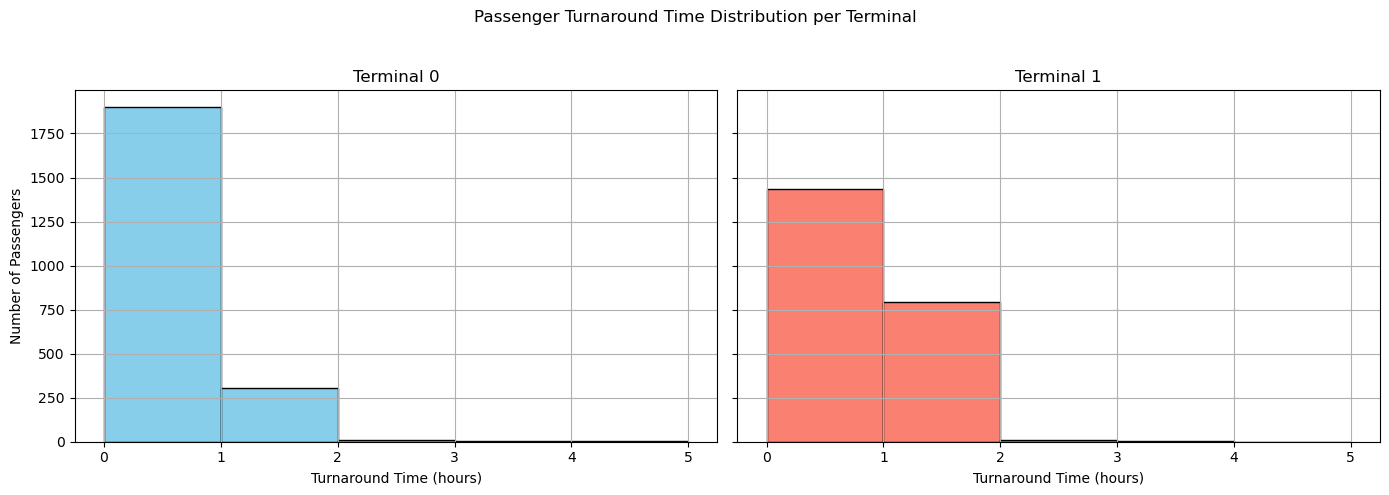

In [22]:

# Define bins (hourly intervals)
max_turnaround = max(terminal_0_df["turn_around_time"].max(), terminal_1_df["turn_around_time"].max())
bins = range(0, int(max_turnaround) + 2)

# Create subplots
fig, axs = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# Terminal 0 histogram
axs[0].hist(terminal_0_df["turn_around_time"], bins=bins, color='skyblue', edgecolor='black')
axs[0].set_title("Terminal 0")
axs[0].set_xlabel("Turnaround Time (hours)")
axs[0].set_ylabel("Number of Passengers")
axs[0].grid(True)

# Terminal 1 histogram
axs[1].hist(terminal_1_df["turn_around_time"], bins=bins, color='salmon', edgecolor='black')
axs[1].set_title("Terminal 1")
axs[1].set_xlabel("Turnaround Time (hours)")
axs[1].grid(True)

plt.suptitle("Passenger Turnaround Time Distribution per Terminal")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

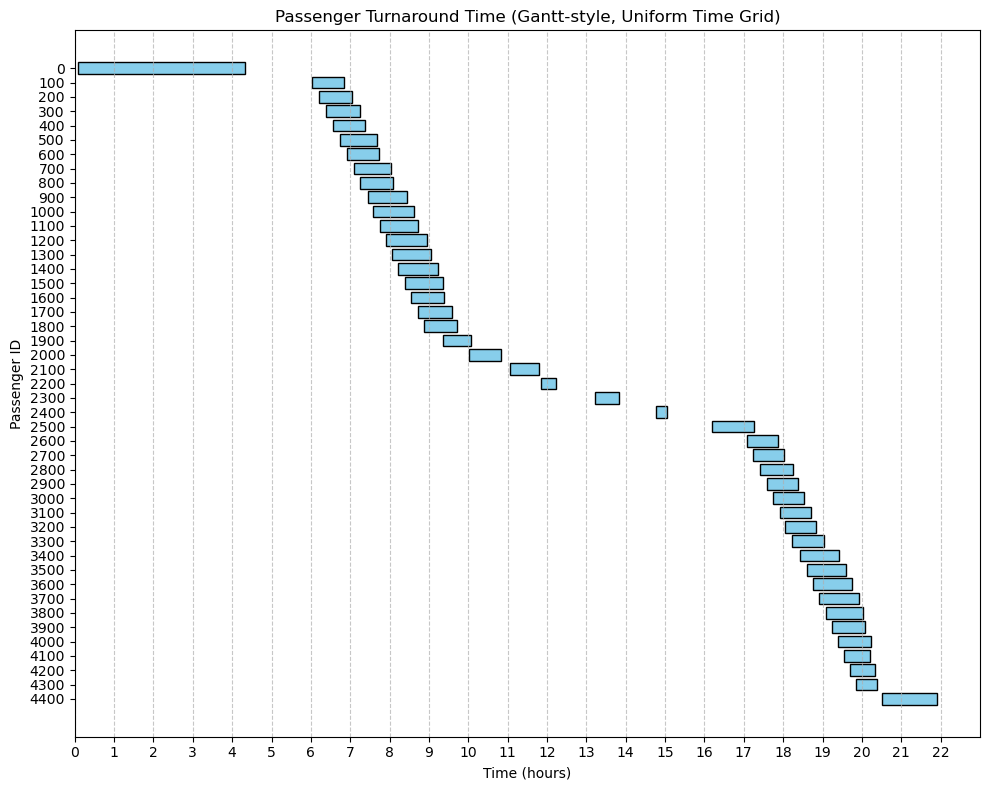

In [23]:

sample_df = passenger_df.iloc[::100].copy()

# Sample by index increments (e.g., every 100th row)
sample_df = passenger_df.iloc[::100].copy()

# Prepare data
starts = sample_df["terminal_arrival_time"]
durations = sample_df["turn_around_time"]
passenger_ids = sample_df["passenger_id"].astype(str)

# Set figure
plt.figure(figsize=(10, 8))
plt.barh(passenger_ids, durations, left=starts, color='skyblue', edgecolor='black')

# Set x-axis gridlines and ticks at every 1 hour
xmin = int(sample_df["terminal_arrival_time"].min())
xmax = int(sample_df["destination_arrival_time"].max()) + 1
plt.xticks(np.arange(xmin, xmax + 1, 1))  # every 1 hour
plt.grid(True, axis='x', linestyle='--', alpha=0.7)

# Labels and layout
plt.xlabel("Time (hours)")
plt.ylabel("Passenger ID")
plt.title("Passenger Turnaround Time (Gantt-style, Uniform Time Grid)")
plt.tight_layout()
plt.gca().invert_yaxis()

plt.show()

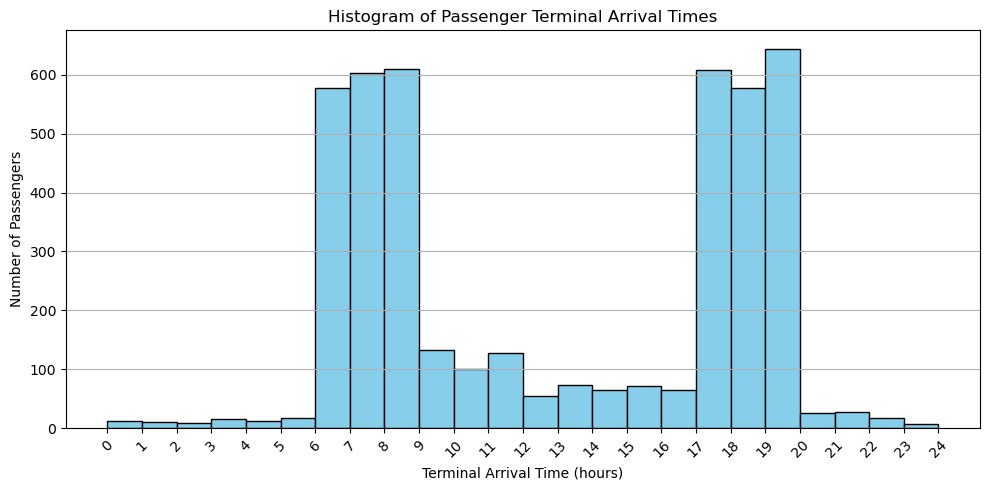

In [24]:
# Define bins: from min to max time, 1-hour step
min_time = int(passenger_df["terminal_arrival_time"].min())
max_time = int(passenger_df["terminal_arrival_time"].max()) + 1
bins = np.arange(min_time, max_time + 1, 1)  # 1-hour bins

# Plot
plt.figure(figsize=(10, 5))
plt.hist(passenger_df["terminal_arrival_time"], bins=bins, color='skyblue', edgecolor='black')

# Labels and styling
plt.xlabel("Terminal Arrival Time (hours)")
plt.ylabel("Number of Passengers")
plt.title("Histogram of Passenger Terminal Arrival Times")
plt.grid(True, axis='y')
plt.xticks(bins, rotation=45)
plt.tight_layout()
plt.show()

In [25]:
average_net_profit = jeep_df['net_profit'].mean()
print(average_net_profit)

1820.4419999999998
